# 05 — XAI Analysis

This notebook applies SHAP and LIME to all three models to examine whether these explainability methods produce consistent and meaningful insights across different model architectures.

**Steps:**
1. Load models and data
2. SHAP analysis — Random Forest
3. SHAP analysis — XGBoost
4. SHAP analysis — Autoencoder
5. LIME analysis — all models
6. Consistency analysis (Spearman correlation)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import joblib
import warnings
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

warnings.filterwarnings('ignore')
shap.initjs()

## 1. Load Models and Data

In [13]:
# Load data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

# Load models
rf = joblib.load('../results/rf_model.pkl')
xgb = joblib.load('../results/xgb_model.pkl')
ae = tf.keras.models.load_model('../results/ae_model.keras')
scaler = joblib.load('../results/ae_scaler.pkl')
best_threshold = np.load('../results/ae_best_threshold.npy')

# Scale test data for autoencoder
X_test_scaled = scaler.transform(X_test)

# Use a small sample for SHAP/LIME — full test set is too slow
sample_idx = X_test.sample(200, random_state=42).index
X_sample = X_test.loc[sample_idx]
X_sample_scaled = X_test_scaled[sample_idx - X_test.index[0]]

# Background sample for SHAP
X_background = X_train.sample(100, random_state=42)

print('Models and data loaded.')
print(f'Sample size for XAI: {len(X_sample)}')

Models and data loaded.
Sample size for XAI: 200


## 2. SHAP — Random Forest

TreeExplainer is used for Random Forest — it is optimised for tree-based models and much faster than the model-agnostic KernelExplainer.

In [14]:
rf_explainer = shap.TreeExplainer(rf)
rf_shap_values = rf_explainer.shap_values(X_sample, check_additivity=False)

# For binary classification, shap_values returns a list — index 1 is fraud class
if isinstance(rf_shap_values, list):
    rf_shap_fraud = rf_shap_values[1]
else:
    rf_shap_fraud = rf_shap_values

# If it's 3D, convert it to 2D
if rf_shap_fraud.ndim == 3:
    rf_shap_fraud = rf_shap_fraud[:, :, 1]

print('RF SHAP values computed.')
print(f'Shape: {rf_shap_fraud.shape}')

RF SHAP values computed.
Shape: (200, 421)


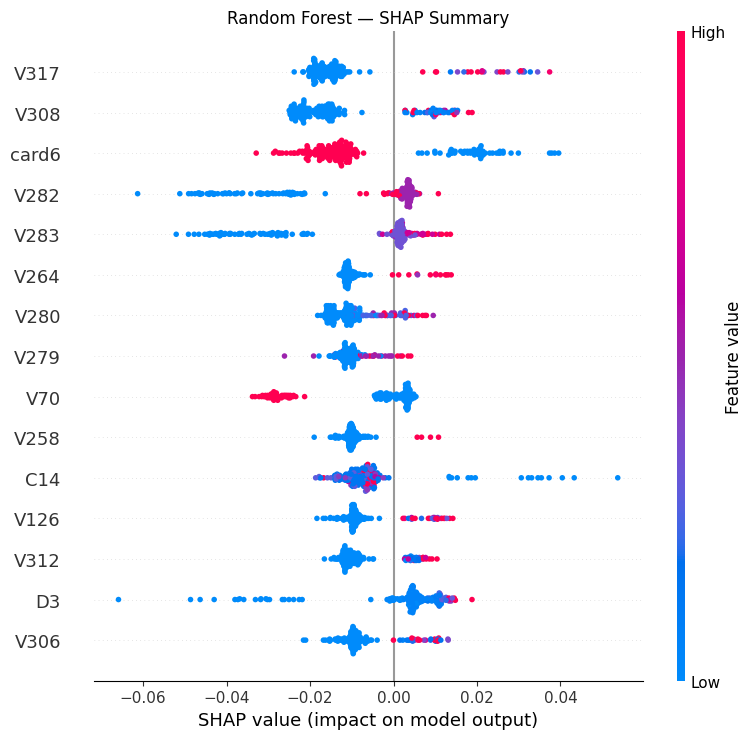

In [15]:
# Summary plot
shap.summary_plot(rf_shap_fraud, X_sample, max_display=15, show=False)
plt.title('Random Forest — SHAP Summary')
plt.tight_layout()
plt.savefig('../results/figures/rf_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Top 10 features by mean absolute SHAP value
rf_mean_shap = pd.Series(
    np.abs(rf_shap_fraud).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

rf_top10 = rf_mean_shap.head(10)
print('RF — Top 10 features (SHAP):')
print(rf_top10)

RF — Top 10 features (SHAP):
V317     0.016957
V308     0.016679
card6    0.016662
V282     0.013856
V283     0.013338
V264     0.010622
V280     0.010452
V279     0.010309
V70      0.010128
V258     0.010091
dtype: float64


## 3. SHAP — XGBoost

Also uses TreeExplainer since XGBoost is a tree-based model.

In [17]:
xgb_explainer = shap.TreeExplainer(xgb)
xgb_shap_values = xgb_explainer.shap_values(X_sample, check_additivity=False)

if isinstance(xgb_shap_values, list):
    xgb_shap_fraud = xgb_shap_values[1]
else:
    xgb_shap_fraud = xgb_shap_values

if xgb_shap_fraud.ndim == 3:
    xgb_shap_fraud = xgb_shap_fraud[:, :, 1]

print('XGBoost SHAP values computed.')

XGBoost SHAP values computed.


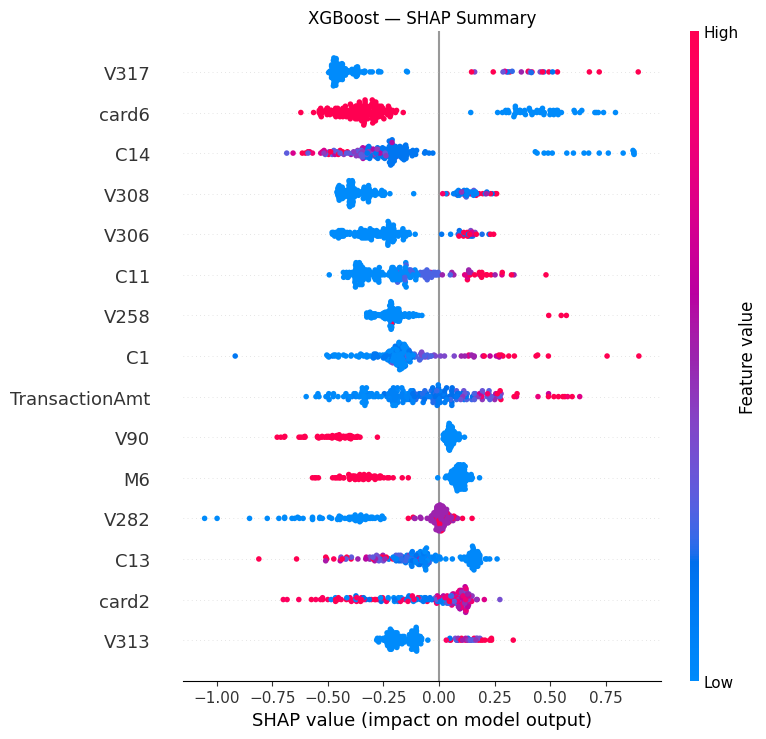

In [18]:
shap.summary_plot(xgb_shap_fraud, X_sample, max_display=15, show=False)
plt.title('XGBoost — SHAP Summary')
plt.tight_layout()
plt.savefig('../results/figures/xgb_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
xgb_mean_shap = pd.Series(
    np.abs(xgb_shap_fraud).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

xgb_top10 = xgb_mean_shap.head(10)
print('XGBoost — Top 10 features (SHAP):')
print(xgb_top10)

XGBoost — Top 10 features (SHAP):
V317              0.431229
card6             0.384749
C14               0.318594
V308              0.309732
V306              0.267048
C11               0.228605
V258              0.220938
C1                0.215024
TransactionAmt    0.205743
V90               0.179395
dtype: float32


## 4. SHAP — Autoencoder

KernelExplainer is used for the Autoencoder since it is model-agnostic. It is slower but works with any model. The reconstruction error is used as the output to explain — higher error means more anomalous.

In [20]:
# Define a predict function that returns reconstruction error
def ae_predict(X):
    X_scaled = scaler.transform(X)
    preds = ae.predict(X_scaled, verbose=0)
    errors = np.mean(np.power(X_scaled - preds, 2), axis=1)
    return errors

# Use a smaller sample for KernelExplainer — it's slow
X_ae_sample = X_sample.iloc[:50]
X_ae_background = X_background.iloc[:50]

ae_explainer = shap.KernelExplainer(ae_predict, X_ae_background)
ae_shap_values = ae_explainer.shap_values(X_ae_sample, nsamples=100)

print('Autoencoder SHAP values computed.')
print(f'Shape: {np.array(ae_shap_values).shape}')

  0%|          | 0/50 [00:00<?, ?it/s]

Autoencoder SHAP values computed.
Shape: (50, 421)


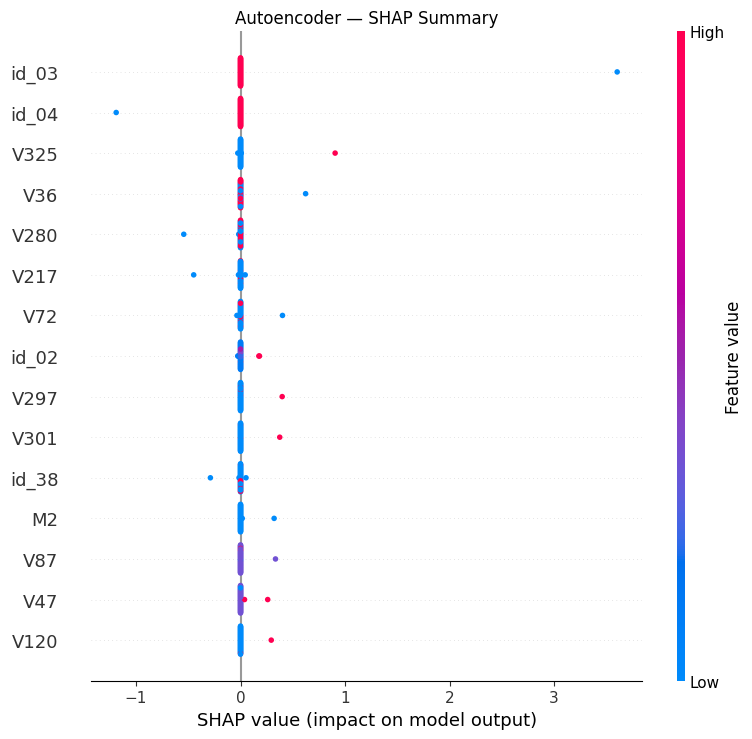

In [21]:
shap.summary_plot(ae_shap_values, X_ae_sample, max_display=15, show=False)
plt.title('Autoencoder — SHAP Summary')
plt.tight_layout()
plt.savefig('../results/figures/ae_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
ae_mean_shap = pd.Series(
    np.abs(np.array(ae_shap_values)).mean(axis=0),
    index=X_ae_sample.columns
).sort_values(ascending=False)

ae_top10 = ae_mean_shap.head(10)
print('Autoencoder — Top 10 features (SHAP):')
print(ae_top10)

Autoencoder — Top 10 features (SHAP):
id_03    0.072079
id_04    0.023797
V325     0.018765
V36      0.012451
V280     0.011210
V217     0.010452
V72      0.009002
id_02    0.008445
V297     0.007970
V301     0.007503
dtype: float64


## 5. LIME Analysis

LIME generates local explanations for individual predictions. We apply it to one fraud instance from the test set for each model and compare which features it highlights.

In [23]:
# Pick one fraud instance from the test set
fraud_idx = y_test[y_test == 1].index[0]
fraud_instance = X_test.loc[fraud_idx].values

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Legitimate', 'Fraud'],
    mode='classification',
    random_state=42
)

In [24]:
# LIME — Random Forest
rf_lime = lime_explainer.explain_instance(
    fraud_instance,
    rf.predict_proba,
    num_features=10
)

rf_lime_features = dict(rf_lime.as_list())
print('RF LIME top features:')
for k, v in rf_lime_features.items():
    print(f'  {k}: {v:.4f}')

RF LIME top features:
  C14 <= 1.00: 0.0422
  V119 <= 1.00: -0.0387
  V19 <= 1.00: 0.0250
  0.00 < V282 <= 1.00: 0.0230
  V91 <= 0.00: 0.0224
  V197 <= 1.00: 0.0223
  V48 <= 0.00: 0.0206
  0.00 < V283 <= 1.00: 0.0205
  V89 <= 0.00: 0.0081
  V28 <= 0.00: 0.0006


In [25]:
# LIME — XGBoost
xgb_lime = lime_explainer.explain_instance(
    fraud_instance,
    xgb.predict_proba,
    num_features=10
)

xgb_lime_features = dict(xgb_lime.as_list())
print('XGBoost LIME top features:')
for k, v in xgb_lime_features.items():
    print(f'  {k}: {v:.4f}')

XGBoost LIME top features:
  C3 <= 0.00: 0.0542
  V117 <= 1.00: 0.0356
  V197 <= 1.00: 0.0205
  C14 <= 1.00: 0.0196
  V138 <= 0.00: 0.0170
  V148 <= 1.00: 0.0166
  V19 <= 1.00: 0.0150
  V113 <= 1.00: 0.0128
  V260 <= 1.00: 0.0127
  V28 <= 0.00: -0.0032


In [26]:
# LIME — Autoencoder
def ae_predict_proba(X):
    X_scaled = scaler.transform(X)
    preds = ae.predict(X_scaled, verbose=0)
    errors = np.mean(np.power(X_scaled - preds, 2), axis=1)
    probs = 1 / (1 + np.exp(-errors))  # sigmoid to convert to probability
    return np.column_stack([1 - probs, probs])

ae_lime = lime_explainer.explain_instance(
    fraud_instance,
    ae_predict_proba,
    num_features=10
)

ae_lime_features = dict(ae_lime.as_list())
print('Autoencoder LIME top features:')
for k, v in ae_lime_features.items():
    print(f'  {k}: {v:.4f}')

Autoencoder LIME top features:
  dist1 > 8.00: -0.0006
  V25 <= 1.00: -0.0003
  V153 <= 1.00: -0.0002
  V198 <= 1.00: -0.0001
  V68 <= 0.00: -0.0001
  id_03 <= 0.00: -0.0001
  V119 <= 1.00: -0.0000
  addr2 <= 87.00: -0.0000
  V27 <= 0.00: -0.0000
  V241 <= 1.00: -0.0000


## 6. Consistency Analysis

Comparing the top-10 SHAP feature rankings across models using Spearman rank correlation. A high correlation means both models agree on which features are most important.

In [27]:
# Align all features to the same index
all_features = X_sample.columns.tolist()

rf_shap_series = pd.Series(np.abs(rf_shap_fraud).mean(axis=0), index=all_features)
xgb_shap_series = pd.Series(np.abs(xgb_shap_fraud).mean(axis=0), index=all_features)
ae_shap_series = pd.Series(np.abs(np.array(ae_shap_values)).mean(axis=0), index=X_ae_sample.columns)
ae_shap_series = ae_shap_series.reindex(all_features, fill_value=0)

# Spearman correlations
corr_rf_xgb, _ = spearmanr(rf_shap_series, xgb_shap_series)
corr_rf_ae, _ = spearmanr(rf_shap_series, ae_shap_series)
corr_xgb_ae, _ = spearmanr(xgb_shap_series, ae_shap_series)

print('SHAP Feature Importance — Spearman Rank Correlation:')
print(f'  RF vs XGBoost:    {corr_rf_xgb:.4f}')
print(f'  RF vs AE:         {corr_rf_ae:.4f}')
print(f'  XGBoost vs AE:    {corr_xgb_ae:.4f}')

SHAP Feature Importance — Spearman Rank Correlation:
  RF vs XGBoost:    0.7236
  RF vs AE:         0.0502
  XGBoost vs AE:    0.1065


In [28]:
# Side-by-side top 10 feature comparison
top10_df = pd.DataFrame({
    'RF': rf_shap_series.rank(ascending=False).head(10),
    'XGBoost': xgb_shap_series.rank(ascending=False).head(10),
    'Autoencoder': ae_shap_series.rank(ascending=False).head(10)
})

print('Top 10 Feature Rankings by Model (SHAP):')
print(top10_df.to_string())

Top 10 Feature Rankings by Model (SHAP):
                   RF  XGBoost  Autoencoder
TransactionID   105.0     24.0        133.0
TransactionDT   104.0     56.0         36.0
TransactionAmt   36.0      9.0        188.0
ProductCD        94.0     38.0        345.5
card1           156.0     22.0        257.0
card2           108.0     14.0        256.0
card3            45.0     46.0        221.0
card4           158.0     98.0         63.0
card5           132.0     28.0         45.0
card6             3.0      2.0        146.0


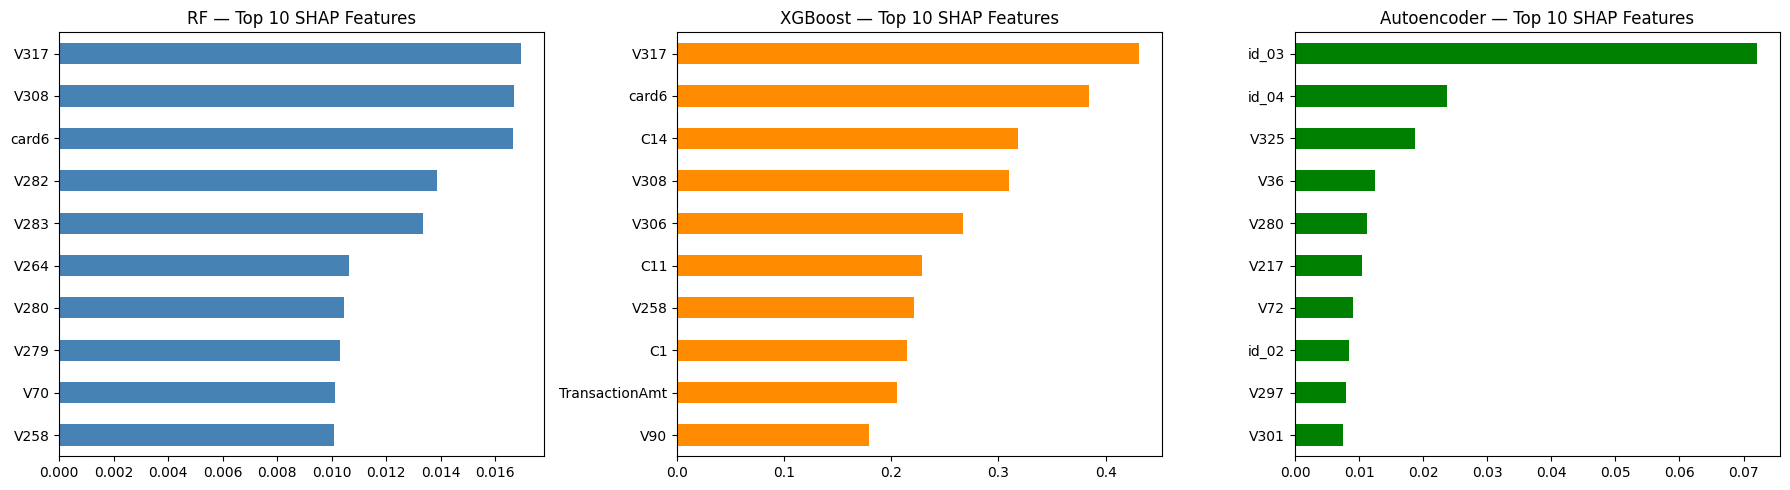

In [29]:
# Bar chart comparison of top 10 SHAP features per model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rf_shap_series.nlargest(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('RF — Top 10 SHAP Features')
axes[0].invert_yaxis()

xgb_shap_series.nlargest(10).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost — Top 10 SHAP Features')
axes[1].invert_yaxis()

ae_shap_series.nlargest(10).plot(kind='barh', ax=axes[2], color='green')
axes[2].set_title('Autoencoder — Top 10 SHAP Features')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../results/figures/shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Save consistency results
consistency = pd.DataFrame({
    'pair': ['RF vs XGBoost', 'RF vs Autoencoder', 'XGBoost vs Autoencoder'],
    'spearman_corr': [corr_rf_xgb, corr_rf_ae, corr_xgb_ae]
})
consistency.to_csv('../results/shap_consistency.csv', index=False)
print('Consistency results saved.')
print(consistency)

Consistency results saved.
                     pair  spearman_corr
0           RF vs XGBoost       0.723644
1       RF vs Autoencoder       0.050248
2  XGBoost vs Autoencoder       0.106505
